# Pandas for Data Analysis

In [2]:
import pandas as pd

## Pandas Series and Dataframe

A series is essentially a column and a dataframe is multidimensional table made up of collection of series.

### How to create pandas series

In [2]:
gender = pd.Series(["Male", "Female", "Female", "Female", "Male", "Male", "Female", "Female", "Female", "Male", "Male"])
gender

0       Male
1     Female
2     Female
3     Female
4       Male
5       Male
6     Female
7     Female
8     Female
9       Male
10      Male
dtype: object

In [3]:
type(gender)

pandas.core.series.Series

In [4]:
country = pd.Series(["Nigeria", "Ethiopia", "Cameroon", "Ghana", "Kenya", "Uganda", "Kenya", "Ethiopia", "Cameroon", "Ghana"])
country

0     Nigeria
1    Ethiopia
2    Cameroon
3       Ghana
4       Kenya
5      Uganda
6       Kenya
7    Ethiopia
8    Cameroon
9       Ghana
dtype: object

In [5]:
age = pd.Series([16, 18, 17,19,20,15,17,14,18,17])
age

0    16
1    18
2    17
3    19
4    20
5    15
6    17
7    14
8    18
9    17
dtype: int64

The indexes of a Series can be manually set also.

In [6]:
age = pd.Series(
    [16, 18, 17,19,20,15,17,14,18,17],
    index = [1,2,3,4,5,6,7,8,9,10]
    )
age

1     16
2     18
3     17
4     19
5     20
6     15
7     17
8     14
9     18
10    17
dtype: int64

### How to create Pandas Dataframe

To create a dataframe, we simply create a data dictionary. That is; the variable will become a key and a list containing the values of the variables becomes the value for the key. then the dictionary is passed into pd.DataFrame() methond

In [7]:
registration_dict = {
    "gender": ["Male", "Female", "Female", "Male", "Male", "Female", "Female", "Female", "Male", "Male"],
    "country": ["Nigeria", "Ethiopia", "Cameroon", "Ghana", "Kenya", "Uganda", "Kenya", "Ethiopia", "Cameroon", "Ghana"],
    "age": [16, 18, 17,19,20,15,17,14,18,17]
}
registration_dict

{'gender': ['Male',
  'Female',
  'Female',
  'Male',
  'Male',
  'Female',
  'Female',
  'Female',
  'Male',
  'Male'],
 'country': ['Nigeria',
  'Ethiopia',
  'Cameroon',
  'Ghana',
  'Kenya',
  'Uganda',
  'Kenya',
  'Ethiopia',
  'Cameroon',
  'Ghana'],
 'age': [16, 18, 17, 19, 20, 15, 17, 14, 18, 17]}

In [8]:
registration_df = pd.DataFrame(registration_dict)
registration_df

,gender,country,age
0,Male,Nigeria,16
1,Female,Ethiopia,18
2,Female,Cameroon,17
3,Male,Ghana,19
4,Male,Kenya,20
5,Female,Uganda,15
6,Female,Kenya,17
7,Female,Ethiopia,14
8,Male,Cameroon,18
9,Male,Ghana,17


The resulting DataFrame will have it's index assigned automatically as with Series and the columns are placed unordered. If you specify a sequence of columns, the DataFrame's columns will be arranged in that order.

In [9]:
registration_df = pd.DataFrame(registration_dict, columns = ["gender", "age", "country"])
registration_df

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


Excercise: Using the below excel data, create a DataFrame.

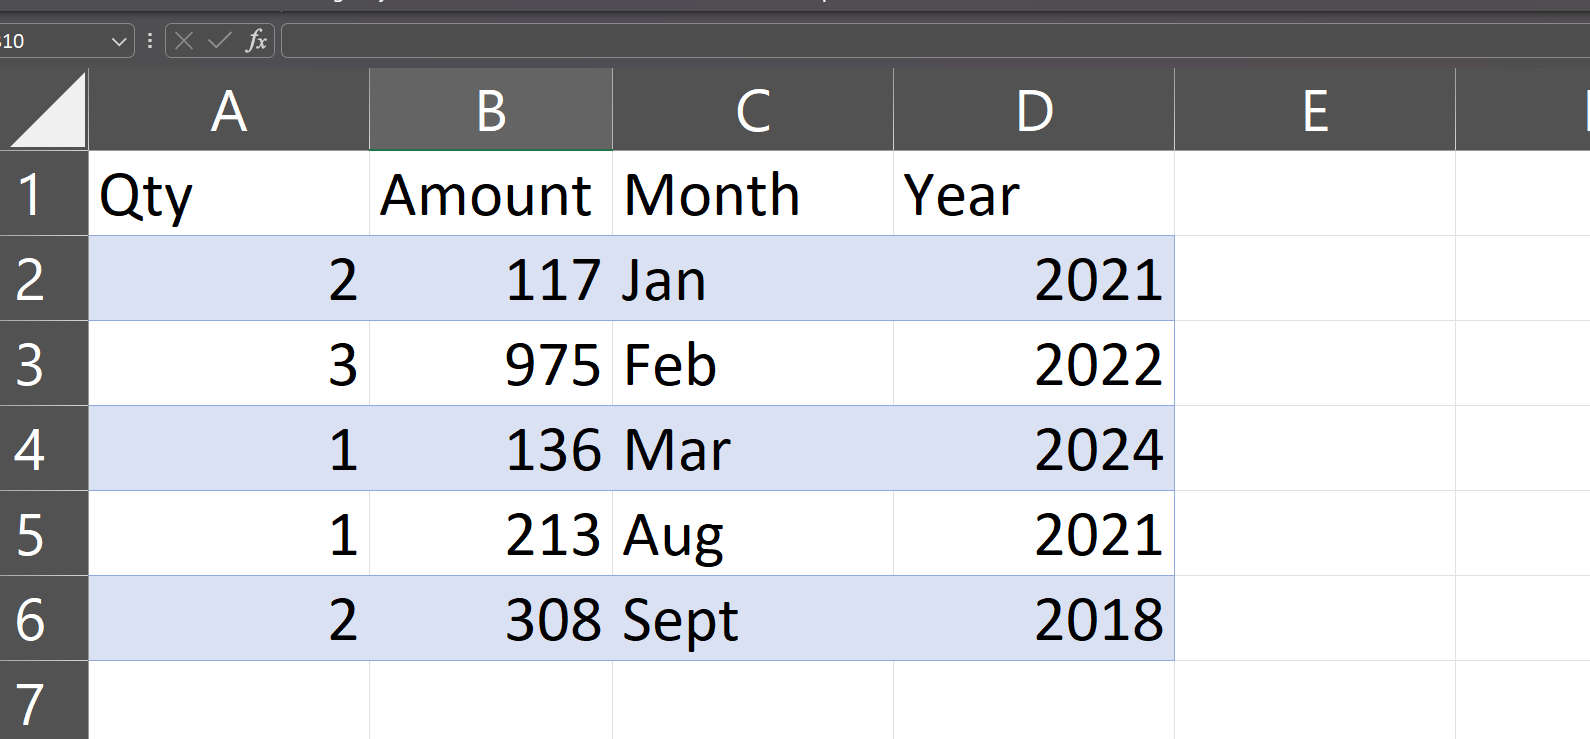

In [10]:
data = {'qty': [2,3,1,1,2],
       'amount': [117,975,136,213,308],
       'month': ['jan', 'feb', 'mar', 'aug', 'sept'],
       'year': [2021,2022,2024,2021,2018]}
df = pd.DataFrame(data)
df

,qty,amount,month,year
0,2,117,jan,2021
1,3,975,feb,2022
2,1,136,mar,2024
3,1,213,aug,2021
4,2,308,sept,2018


In [11]:
df.iloc[0:5:2, 0:3:2]


,qty,month
0,2,jan
2,1,mar
4,2,sept


In [12]:
df.loc[:2, ["month","year"]]

,month,year
0,jan,2021
1,feb,2022
2,mar,2024


## Attributes and Methods of DataFrame

### .head()
gives the first 5 rows
### .info()
gives the structure of the DataFrame
### .shape
outputs just a tuple of (rows, columns)
### .index and .columns
used to see the the list of observations and column names in our df.

In [13]:
df.index

RangeIndex(start=0, stop=5, step=1)

In [14]:
df.columns

Index(['qty', 'amount', 'month', 'year'], dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   qty     5 non-null      int64 
 1   amount  5 non-null      int64 
 2   month   5 non-null      object
 3   year    5 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 292.0+ bytes


In [16]:
df.head()

,qty,amount,month,year
0,2,117,jan,2021
1,3,975,feb,2022
2,1,136,mar,2024
3,1,213,aug,2021
4,2,308,sept,2018


In [17]:
df.shape

(5, 4)

## Selection and Indexing of Dataframe 

A column in a DataFrame can be retrieved as a Series

In [18]:
registration_df["country"] 

#OR

# registration_df.country

0     Nigeria
1    Ethiopia
2    Cameroon
3       Ghana
4       Kenya
5      Uganda
6       Kenya
7    Ethiopia
8    Cameroon
9       Ghana
Name: country, dtype: object

Note that the df.column_name will fail when the varable name has special character like the "space character".  

To select two or more columns, we pass the list of the columns into the into the indexing

In [19]:
registration_df[['age', 'country']]

,age,country
0,16,Nigeria
1,18,Ethiopia
2,17,Cameroon
3,19,Ghana
4,20,Kenya
5,15,Uganda
6,17,Kenya
7,14,Ethiopia
8,18,Cameroon
9,17,Ghana


### ``.loc[]`` and ``iloc[]``
The ``.loc[]`` and ``iloc[]`` DataFrame attribute enable you to select a subset of the rows and columns from a DataFrame with NumPy-like notation using either axis labels (``df.loc[]``) or integers (``df.iloc[]``). The general format for both ``.loc[]`` and ``.iloc[]`` are ``df.loc[row, col]`` and ``iloc[row, col]`` where ``df`` is the name of the DataFrame while ``[row, col] specifies the row and column index of the DataFrame. Remember, Python counting starts at 0, so the first row is row zero

### ``.loc[]``
Here the rows to extract is passed as ``a:b`` while the columns is specified by a list.

In [20]:
registration_df.loc[0:3, ["country", "age"]]

,country,age
0,Nigeria,16
1,Ethiopia,18
2,Cameroon,17
3,Ghana,19


Please not that ``.loc`` index position is inclusive. i.e 0:5 means 0,1,2,3,4,5. This is different from numpy array that have 0:5 as 0,1,2,3,4

In [21]:
registration_df.loc[5:8, ["gender"]]

,gender
5,Female
6,Female
7,Female
8,Male


In [22]:
registration_df.loc[6:, ["gender"]]

,gender
6,Female
7,Female
8,Male
9,Male


### ```.iloc[]```


In [23]:
registration_df.iloc[0:5, [0,1]]

,gender,age
0,Male,16
1,Female,18
2,Female,17
3,Male,19
4,Male,20


## How to rename column in DataFrame

We use ``.rename`` method to rename certain or all columns in a DataFrame via a dict.

In [24]:
registration_df

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


In [55]:
# registration_df.rename(columns=
#     {
#         "country": "COUNTRY",
#         "gender": "GENDER"
#     }
# )

# OR

# registration_df.rename(
#     {
#         "country": "Country",
#         "gender": "Gender"
#     },
#     axis = 1
# )

,GENDER,age,COUNTRY
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


In [26]:
registration_df.rename(columns=
    {
        "country": "COUNTRY",
        "gender": "GENDER"
    }, inplace = True
)

In [27]:
registration_df

,GENDER,age,COUNTRY
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


In [28]:
registration_df.rename(str.lower, axis='columns')

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


In [29]:
registration_df.rename(str.upper, axis='columns', inplace  = True)

In [30]:
registration_df

,GENDER,AGE,COUNTRY
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


In [31]:
registration_df.rename(str.lower, axis='columns', inplace  = True)

In [32]:
registration_df

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


In [33]:
registration_df.rename({"GENDER":"SEX"}, axis='columns')

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


In [57]:
registration_df.rename({1: 2, 2: 4}, axis='index')

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
4,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


In [35]:
registration_df

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


## Adding Variables (Columns) to the DataFrame

In [61]:
a = registration_df["age"]
b = [n+5 if n<18 else n for n in a]  #  ["Positive" if n > 0 else "Negative" for n in numbers]
registration_df["age_plus_5"] = b

In [62]:
registration_df

,gender,age,country,age_plus_5
0,Male,16,Nigeria,21
1,Female,18,Ethiopia,18
2,Female,17,Cameroon,22
3,Male,19,Ghana,19
4,Male,20,Kenya,20
5,Female,15,Uganda,20
6,Female,17,Kenya,22
7,Female,14,Ethiopia,19
8,Male,18,Cameroon,18
9,Male,17,Ghana,22


## Dropping/ removing Variables (Columns) from the DataFrame

``.drop()`` method is used to drop column(s) from a particular df.

In [38]:
registration_df

,gender,age,country,age_plus_5
0,Male,16,Nigeria,21
1,Female,18,Ethiopia,23
2,Female,17,Cameroon,22
3,Male,19,Ghana,24
4,Male,20,Kenya,25
5,Female,15,Uganda,20
6,Female,17,Kenya,22
7,Female,14,Ethiopia,19
8,Male,18,Cameroon,23
9,Male,17,Ghana,22


In [39]:
registration_df.columns

Index(['gender', 'age', 'country', 'age_plus_5'], dtype='object')

In [40]:
registration_df.drop('age_plus_5', axis="columns")

# Or

# registration_df.drop(columns=["age_plus_5"])

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


In [41]:
registration_df.drop('age_plus_5', axis="columns", inplace = True)

# Or

# registration_df.drop(columns="age_plus_5", inplace=True)

In [42]:
registration_df

,gender,age,country
0,Male,16,Nigeria
1,Female,18,Ethiopia
2,Female,17,Cameroon
3,Male,19,Ghana
4,Male,20,Kenya
5,Female,15,Uganda
6,Female,17,Kenya
7,Female,14,Ethiopia
8,Male,18,Cameroon
9,Male,17,Ghana


## Conditional Filtering of a DataFrame

In [43]:
# First is to create a Boolean Mask
registration_df["gender"]=="Female"

0    False
1     True
2     True
3    False
4    False
5     True
6     True
7     True
8    False
9    False
Name: gender, dtype: bool

In [64]:
# Then pass the boolean mask into the df indexer
registration_df[registration_df["gender"]=="Female"]

,gender,age,country,age_plus_5
1,Female,18,Ethiopia,18
2,Female,17,Cameroon,22
5,Female,15,Uganda,20
6,Female,17,Kenya,22
7,Female,14,Ethiopia,19


## How to import data with pandas

From the previous examples, we can see that it is so tedious to start creating DataFrame from scratch. ...  

The first thing in importing generally is to know your working directory

### Importing a csv

In [76]:
pwd

'C:\\Users\\OMEN\\OneDrive\\Desktop\\aptech'

In [78]:
ls

 Volume in drive C has no label.
 Volume Serial Number is 9CF0-248F

 Directory of C:\Users\OMEN\OneDrive\Desktop\aptech

02/10/2026  10:08 AM    <DIR>          .
02/10/2026  09:35 AM    <DIR>          ..
02/09/2026  10:06 AM    <DIR>          .ipynb_checkpoints
11/20/2025  07:01 PM    <DIR>          __pycache__
11/17/2025  10:28 AM             7,960 assignment_3.ipynb
12/16/2025  07:19 PM             4,266 assignment_file_exception_handling.ipynb
12/03/2025  11:50 AM             4,257 assignment2B.ipynb
12/10/2025  10:50 AM                15 attendance.txt
02/09/2026  12:36 PM        32,761,488 AURELI_1.PDF
02/06/2026  12:07 PM           302,448 DATABASE MANAGEMENT WITH MYSQL. subqueries docx.pdf
01/26/2026  12:52 PM           262,055 DATABASE MANAGENT WITH MYSQ1--- aggregate functions.pdf
01/26/2026  12:52 PM           132,637 DATABASE MANAGENT WITH MYSQl more aggregate functions.pdf
01/26/2026  12:01 PM        93,402,533 employees (2).sql
02/02/2026  10:34 AM             4,410 exerc

In [65]:
dir

<function dir>

In [75]:
cd C:\Users\OMEN\OneDrive\Desktop\aptech

C:\Users\OMEN\OneDrive\Desktop\aptech


In [2]:
pd.read_csv(r"C:\Users\OMEN\OneDrive\Desktop\aptech\mexico-city-real-estate-1.csv")

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851900,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...
1,sell,house,|Iztapalapa|Distrito Federal|México|,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...
2,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...
3,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481480,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...
4,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1902642,-86.8198375",875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4623,sell,apartment,|Benito Juárez|Quintana Roo|México|,"20.797201,-86.967773",200000.0,USD,3761700.00,200000.00,NaN,240.0,NaN,833.333333,NaN,1.0,NaN,http://cancun.properati.com.mx/fmik_venta_depa...
4624,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.303758,-99.223733",10000000.0,MXN,10144274.75,539345.23,200.0,NaN,2696.726150,NaN,NaN,NaN,NaN,http://lomas-del-pedregal.properati.com.mx/pym...
4625,sell,house,|Solidaridad|Quintana Roo|México|,"20.613375,-87.089897",480000.0,USD,9028080.00,480000.00,451.0,245.0,1064.301552,1959.183673,2.0,NaN,NaN,http://playa-del-carmen.properati.com.mx/bvwt_...
4626,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,"23.634501,-102.552788",2453800.0,MXN,2431602.18,129282.09,NaN,67.0,NaN,36623.880600,NaN,NaN,NaN,http://cuauhtemoc.properati.com.mx/p2op_venta_...


In [3]:
a= pd.read_csv(r"C:\Users\OMEN\OneDrive\Desktop\aptech\mexico-city-real-estate-2.csv")
a.head(10)
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4628 entries, 0 to 4627
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   4628 non-null   object 
 1   property_type               4628 non-null   object 
 2   place_with_parent_names     4628 non-null   object 
 3   lat-lon                     4145 non-null   object 
 4   price                       4552 non-null   float64
 5   currency                    4552 non-null   object 
 6   price_aprox_local_currency  4552 non-null   float64
 7   price_aprox_usd             4552 non-null   float64
 8   surface_total_in_m2         1781 non-null   float64
 9   surface_covered_in_m2       4445 non-null   float64
 10  price_usd_per_m2            1260 non-null   float64
 11  price_per_m2                4262 non-null   float64
 12  floor                       322 non-null    float64
 13  rooms                       117 n

### Importing Excel file

In [ ]:
pd.read_excel(file_path)

### Importing a JSON file

In [ ]:
pd.read_json(file_path)

## Exporting Data with Pandas

```python
df.to_csv(file_path)
df.to_excel(file_path)
df.to_json(file_path)
```

In [119]:
a.notnull()

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,True,True,True,True,True,True,True,True,True,True,True,True,False,False,False,True
1,True,True,True,True,True,True,True,True,False,True,False,True,False,False,False,True
2,True,True,True,True,True,True,True,True,False,True,False,True,False,False,False,True
3,True,True,True,True,True,True,True,True,True,True,False,True,False,False,False,True
4,True,True,True,True,True,True,True,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4623,True,True,True,True,True,True,True,True,False,True,False,True,False,False,False,True
4624,True,True,True,True,True,True,True,True,False,True,False,True,False,False,False,True
4625,True,True,True,False,True,True,True,True,False,True,False,True,False,False,False,True
4626,True,True,True,True,True,True,True,True,False,True,False,True,False,False,False,True


In [64]:
a.count()

operation                     4628
property_type                 4628
place_with_parent_names       4628
lat-lon                       4145
price                         4552
currency                      4552
price_aprox_local_currency    4552
price_aprox_usd               4552
surface_total_in_m2           1781
surface_covered_in_m2         4445
price_usd_per_m2              1260
price_per_m2                  4262
floor                          322
rooms                          117
expenses                         1
properati_url                 4628
dtype: int64

1. filter all the rows whose property type is "apartment". Save it as "apartment_df". Display the first 3 rows
   
3. in the "apartment_df", drop the variables "property_type" and "property_url".

In [4]:
apartment_df = a[a['property_type']=="apartment"]
apartment_df.head(3)

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.516777,-99.160149",1200000.0,MXN,1189144.46,63223.78,88.0,88.0,718.452046,13636.36364,NaN,NaN,NaN,http://gustavo-a-madero.properati.com.mx/r644_...
1,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.466724,-99.131614",480000.0,MXN,475657.74,25289.51,NaN,48.0,NaN,10000.00000,NaN,NaN,NaN,http://vallejo.properati.com.mx/mz4c_venta_dep...
2,sell,apartment,|Álvaro Obregón|Distrito Federal|México|,"19.33228,-99.243934",4559261.0,MXN,4518016.68,240211.43,NaN,126.0,NaN,36184.61111,NaN,NaN,NaN,http://alvaro-obregon.properati.com.mx/jh8j_ve...


In [136]:
apartment_df.drop(["property_type","properati_url"], axis= 1, inplace= True)

KeyError: "['property_type', 'properati_url'] not found in axis"

In [8]:
a.dropna(axis=1)


,operation,property_type,place_with_parent_names,properati_url
0,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,http://gustavo-a-madero.properati.com.mx/r644_...
1,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,http://vallejo.properati.com.mx/mz4c_venta_dep...
2,sell,apartment,|Álvaro Obregón|Distrito Federal|México|,http://alvaro-obregon.properati.com.mx/jh8j_ve...
3,sell,apartment,|Benito Juárez|Quintana Roo|México|,http://cancun.properati.com.mx/qus8_venta_depa...
4,sell,apartment,|Benito Juárez|Distrito Federal|México|,http://benito-juarez.properati.com.mx/q5my_ven...
...,...,...,...,...
4623,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,http://cuauhtemoc.properati.com.mx/izni_venta_...
4624,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,http://cuauhtemoc.properati.com.mx/q6qb_venta_...
4625,sell,apartment,|Coyoacán|Distrito Federal|México|,http://la-otra-banda-coyoacan.properati.com.mx...
4626,sell,house,|Benito Juárez|Quintana Roo|México|,http://benito-juarez-quintana-roo.properati.co...


In [12]:
a.operation.nunique() #returns the number of distinct elements
a.operation.unique() #returns an array of distinct elements

array(['sell'], dtype=object)

In [69]:
# This splits the string and expands it into two new columns
apartment_df[['lat', 'lon']] = apartment_df['lat-lon'].str.split(',',expand=True)


C:\Users\OMEN\AppData\Local\Temp\ipykernel_12716\3048867641.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apartment_df[['lat', 'lon']] = apartment_df['lat-lon'].str.split(',',expand=True)


In [71]:
apartment_df.loc[:, ['lat', 'lon']] = apartment_df['lat-lon'].str.split(',', expand=True).values


In [5]:
pd.DataFrame(apartment_df, columns = ['operation', 'property_type', 'place_with_parent_names', 'lat-lon', 'lat', 'lon',
       'price', 'currency', 'price_aprox_local_currency', 'price_aprox_usd',
       'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2',
       'price_per_m2', 'floor', 'rooms', 'expenses', 'properati_url'])

,operation,property_type,place_with_parent_names,lat-lon,lat,lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.516777,-99.160149",NaN,NaN,1200000.0,MXN,1189144.46,63223.78,88.0,88.0,718.452046,13636.363640,NaN,NaN,NaN,http://gustavo-a-madero.properati.com.mx/r644_...
1,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.466724,-99.131614",NaN,NaN,480000.0,MXN,475657.74,25289.51,NaN,48.0,NaN,10000.000000,NaN,NaN,NaN,http://vallejo.properati.com.mx/mz4c_venta_dep...
2,sell,apartment,|Álvaro Obregón|Distrito Federal|México|,"19.33228,-99.243934",NaN,NaN,4559261.0,MXN,4518016.68,240211.43,NaN,126.0,NaN,36184.611110,NaN,NaN,NaN,http://alvaro-obregon.properati.com.mx/jh8j_ve...
3,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1105772788,-86.8537859927",NaN,NaN,3808088.0,MXN,3774533.79,200682.34,0.0,171.0,NaN,22269.520470,NaN,NaN,NaN,http://cancun.properati.com.mx/qus8_venta_depa...
4,sell,apartment,|Benito Juárez|Distrito Federal|México|,"19.39365,-99.14769",NaN,NaN,1730000.0,MXN,1714349.82,91147.61,NaN,100.0,NaN,17300.000000,NaN,NaN,NaN,http://benito-juarez.properati.com.mx/q5my_ven...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4620,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.295734,-99.146996",NaN,NaN,1113000.0,MXN,1102931.38,58640.05,NaN,80.0,NaN,13912.500000,NaN,NaN,NaN,http://villa-lazaro-cardenas.properati.com.mx/...
4622,sell,apartment,|Solidaridad|Quintana Roo|México|,"20.6456,-87.060983",NaN,NaN,350000.0,USD,6582975.00,350000.00,NaN,150.0,NaN,2333.333333,NaN,NaN,NaN,http://solidaridad-quintana-roo.properati.com....
4623,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,"23.634501,-102.552788",NaN,NaN,739000.0,MXN,732314.77,38935.31,NaN,76.0,NaN,9723.684211,NaN,NaN,NaN,http://cuauhtemoc.properati.com.mx/izni_venta_...
4624,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,"19.409369,-99.171906",NaN,NaN,3845484.0,MXN,3810696.70,202605.03,NaN,90.0,NaN,42727.600000,NaN,NaN,NaN,http://cuauhtemoc.properati.com.mx/q6qb_venta_...


In [79]:
pd.DataFrame(apartment_df, columns = ['operation', 'property_type', 'place_with_parent_names', 'lat-lon', 'lat', 'lon',
       'price', 'currency', 'price_aprox_local_currency', 'price_aprox_usd',
       'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2',
       'price_per_m2', 'floor', 'rooms', 'expenses', 'properati_url'])

,operation,property_type,place_with_parent_names,lat-lon,lat,lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.516777,-99.160149",19.516777,-99.160149,1200000.0,MXN,1189144.46,63223.78,88.0,88.0,718.452046,13636.363640,NaN,NaN,NaN,http://gustavo-a-madero.properati.com.mx/r644_...
1,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.466724,-99.131614",19.466724,-99.131614,480000.0,MXN,475657.74,25289.51,NaN,48.0,NaN,10000.000000,NaN,NaN,NaN,http://vallejo.properati.com.mx/mz4c_venta_dep...
2,sell,apartment,|Álvaro Obregón|Distrito Federal|México|,"19.33228,-99.243934",19.33228,-99.243934,4559261.0,MXN,4518016.68,240211.43,NaN,126.0,NaN,36184.611110,NaN,NaN,NaN,http://alvaro-obregon.properati.com.mx/jh8j_ve...
3,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1105772788,-86.8537859927",21.1105772788,-86.8537859927,3808088.0,MXN,3774533.79,200682.34,0.0,171.0,NaN,22269.520470,NaN,NaN,NaN,http://cancun.properati.com.mx/qus8_venta_depa...
4,sell,apartment,|Benito Juárez|Distrito Federal|México|,"19.39365,-99.14769",19.39365,-99.14769,1730000.0,MXN,1714349.82,91147.61,NaN,100.0,NaN,17300.000000,NaN,NaN,NaN,http://benito-juarez.properati.com.mx/q5my_ven...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4620,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.295734,-99.146996",19.295734,-99.146996,1113000.0,MXN,1102931.38,58640.05,NaN,80.0,NaN,13912.500000,NaN,NaN,NaN,http://villa-lazaro-cardenas.properati.com.mx/...
4622,sell,apartment,|Solidaridad|Quintana Roo|México|,"20.6456,-87.060983",20.6456,-87.060983,350000.0,USD,6582975.00,350000.00,NaN,150.0,NaN,2333.333333,NaN,NaN,NaN,http://solidaridad-quintana-roo.properati.com....
4623,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,"23.634501,-102.552788",23.634501,-102.552788,739000.0,MXN,732314.77,38935.31,NaN,76.0,NaN,9723.684211,NaN,NaN,NaN,http://cuauhtemoc.properati.com.mx/izni_venta_...
4624,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,"19.409369,-99.171906",19.409369,-99.171906,3845484.0,MXN,3810696.70,202605.03,NaN,90.0,NaN,42727.600000,NaN,NaN,NaN,http://cuauhtemoc.properati.com.mx/q6qb_venta_...


In [100]:
pd.DataFrame(apartment_df, columns = ['operation', 'property_type', 'place_with_parent_names', 'lat-lon', 'lat', 'lon',
       'price', 'currency', 'price_aprox_local_currency', 'price_aprox_usd',
       'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2',
       'price_per_m2'])

,operation,property_type,place_with_parent_names,lat-lon,lat,lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2
0,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.516777,-99.160149",19.516777,-99.160149,1200000.0,MXN,1189144.46,234.134400,88.0,88.0,718.452046,13636.363640
1,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.466724,-99.131614",19.466724,-99.131614,480000.0,MXN,475657.74,93.653760,NaN,48.0,NaN,10000.000000
2,sell,apartment,|Álvaro Obregón|Distrito Federal|México|,"19.33228,-99.243934",19.33228,-99.243934,4559261.0,MXN,4518016.68,889.566532,NaN,126.0,NaN,36184.611110
3,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1105772788,-86.8537859927",21.1105772788,-86.8537859927,3808088.0,MXN,3774533.79,743.003666,0.0,171.0,NaN,22269.520470
4,sell,apartment,|Benito Juárez|Distrito Federal|México|,"19.39365,-99.14769",19.39365,-99.14769,1730000.0,MXN,1714349.82,337.543760,NaN,100.0,NaN,17300.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4620,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.295734,-99.146996",19.295734,-99.146996,1113000.0,MXN,1102931.38,217.159656,NaN,80.0,NaN,13912.500000
4622,sell,apartment,|Solidaridad|Quintana Roo|México|,"20.6456,-87.060983",20.6456,-87.060983,350000.0,USD,6582975.00,68.289200,NaN,150.0,NaN,2333.333333
4623,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,"23.634501,-102.552788",23.634501,-102.552788,739000.0,MXN,732314.77,144.187768,NaN,76.0,NaN,9723.684211
4624,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,"19.409369,-99.171906",19.409369,-99.171906,3845484.0,MXN,3810696.70,750.300074,NaN,90.0,NaN,42727.600000


In [6]:
apartment_df.loc[:,'price'] *=  0.058
apartment_df

,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.516777,-99.160149",69600.000,MXN,1189144.46,63223.78,88.0,88.0,718.452046,13636.363640,NaN,NaN,NaN,http://gustavo-a-madero.properati.com.mx/r644_...
1,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.466724,-99.131614",27840.000,MXN,475657.74,25289.51,NaN,48.0,NaN,10000.000000,NaN,NaN,NaN,http://vallejo.properati.com.mx/mz4c_venta_dep...
2,sell,apartment,|Álvaro Obregón|Distrito Federal|México|,"19.33228,-99.243934",264437.138,MXN,4518016.68,240211.43,NaN,126.0,NaN,36184.611110,NaN,NaN,NaN,http://alvaro-obregon.properati.com.mx/jh8j_ve...
3,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1105772788,-86.8537859927",220869.104,MXN,3774533.79,200682.34,0.0,171.0,NaN,22269.520470,NaN,NaN,NaN,http://cancun.properati.com.mx/qus8_venta_depa...
4,sell,apartment,|Benito Juárez|Distrito Federal|México|,"19.39365,-99.14769",100340.000,MXN,1714349.82,91147.61,NaN,100.0,NaN,17300.000000,NaN,NaN,NaN,http://benito-juarez.properati.com.mx/q5my_ven...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4620,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.295734,-99.146996",64554.000,MXN,1102931.38,58640.05,NaN,80.0,NaN,13912.500000,NaN,NaN,NaN,http://villa-lazaro-cardenas.properati.com.mx/...
4622,sell,apartment,|Solidaridad|Quintana Roo|México|,"20.6456,-87.060983",20300.000,USD,6582975.00,350000.00,NaN,150.0,NaN,2333.333333,NaN,NaN,NaN,http://solidaridad-quintana-roo.properati.com....
4623,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,"23.634501,-102.552788",42862.000,MXN,732314.77,38935.31,NaN,76.0,NaN,9723.684211,NaN,NaN,NaN,http://cuauhtemoc.properati.com.mx/izni_venta_...
4624,sell,apartment,|Cuauhtémoc|Distrito Federal|México|,"19.409369,-99.171906",223038.072,MXN,3810696.70,202605.03,NaN,90.0,NaN,42727.600000,NaN,NaN,NaN,http://cuauhtemoc.properati.com.mx/q6qb_venta_...
